In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python

import io # Input/Output Module
import os # OS interfaces
import cv2 # OpenCV package
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import random
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
from skimage.feature import hog
from urllib import request # module for opening HTTP requests
from matplotlib import pyplot as plt # Plotting library
from sklearn.manifold import TSNE
from sklearn.svm import SVC
from sklearn.model_selection import cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from io import BytesIO
from PIL import Image
from skimage.color import rgb2gray

KUL H02A5a Computer Vision: Group Assignment 1
---------------------------------------------------------------
Student numbers: <span style="color:red">r1, r2, r3, r4, r5</span>.

The goal of this assignment is to explore more advanced techniques for constructing features that better describe objects of interest and to perform face recognition using these features. This assignment will be delivered in groups of 5 (either composed by you or randomly assigned by your TA's).

In this assignment you are a group of computer vision experts that have been invited to ECCV 2025 to do a tutorial about  "Feature representations, then and now". To prepare the tutorial you are asked to participate in a kaggle competition and to release a notebook that can be easily studied by the tutorial participants. Your target audience is: (master) students who want to get a first hands-on introduction to the techniques that you apply.

---------------------------------------------------------------
This notebook is structured as follows:
0. Data loading & Preprocessing
1. Feature Representations
2. Evaluation Metrics 
3. Classifiers
4. Experiments
5. Publishing best results
6. Discussion

Make sure that your notebook is **self-contained** and **fully documented**. Walk us through all steps of your code. Treat your notebook as a tutorial for students who need to get a first hands-on introduction to the techniques that you apply. Provide strong arguments for the design choices that you made and what insights you got from your experiments. Make use of the *Group assignment* forum/discussion board on Toledo if you have any questions.

Fill in your student numbers above and get to it! Good luck! 


<div class="alert alert-block alert-info">
<b>NOTE:</b> This notebook is just a example/template, feel free to adjust in any way you please! Just keep things organised and document accordingly!
</div>

<div class="alert alert-block alert-info">
<b>NOTE:</b> Clearly indicate the improvements that you make!!! You can for instance use titles like: <i>3.1. Improvement: Non-linear SVM with RBF Kernel.<i>
</div>
    
---------------------------------------------------------------
# 0. Data loading & Preprocessing

## 0.1. Loading data
The training set is many times smaller than the test set and this might strike you as odd, however, this is close to a real world scenario where your system might be put through daily use! In this session we will try to do the best we can with the data that we've got! 

In [5]:
# Input data files are available in the read-only "../input/" directory

train = pd.read_csv(
    '/kaggle/input/kul-computer-vision-ga-1-2025/train_set.csv', index_col = 0)
train.index = train.index.rename('id')

test = pd.read_csv(
    '/kaggle/input/kul-computer-vision-ga-1-2025/test_set.csv', index_col = 0)
test.index = test.index.rename('id')

# read the images as numpy arrays and store in "img" column
train['img'] = [cv2.cvtColor(np.load('/kaggle/input/kul-computer-vision-ga-1-2025/train/train_{}.npy'.format(index), allow_pickle=False), cv2.COLOR_BGR2RGB) 
                for index, row in train.iterrows()]

test['img'] = [cv2.cvtColor(np.load('/kaggle/input/kul-computer-vision-ga-1-2025/test/test_{}.npy'.format(index), allow_pickle=False), cv2.COLOR_BGR2RGB) 
                for index, row in test.iterrows()]
  

train_size, test_size = len(train),len(test)

"The training set contains {} examples, the test set contains {} examples.".format(train_size, test_size)

'The training set contains 80 examples, the test set contains 1816 examples.'

# 0.1.1 Data Augmentation
As we only have 80 training data points out of ~1900, we need more

In [6]:
# 1. Vertical flip
train_flipped = train.copy()

train_flipped['img'] = [cv2.flip(img, 1) for img in train_flipped['img']]  # MAKE SURE VALUE IS 1 in (img,1)

# Add a suffix to the index to distinguish the flipped images
train_flipped.index = [f"{idx}_flipped" for idx in train_flipped.index]

# Combine the original and flipped datasets
train = pd.concat([train, train_flipped])

print(f"The augmented training set contains {len(train)} examples.")

The augmented training set contains 160 examples.


In [7]:

def random_rotation(image, min_angle=5, max_angle=15):

    # Determine the sign of the rotation (clockwise or counter-clockwise)
    sign = random.choice([-1, 1])
    
    # Generate a random angle between min_angle and max_angle
    angle = random.uniform(min_angle, max_angle) * sign
    
    # Get image dimensions
    height, width = image.shape[:2]
    
    # Calculate the rotation matrix
    center = (width // 2, height // 2)
    rotation_matrix = cv2.getRotationMatrix2D(center, angle, 1.0)
    
    # Apply the rotation
    rotated_image = cv2.warpAffine(image, rotation_matrix, (width, height), 
                                  flags=cv2.INTER_LINEAR, borderMode=cv2.BORDER_CONSTANT, 
                                  borderValue=(0, 0, 0))
    
    return rotated_image

# 3. Flipped + Rotated
train_flipped_rotated = train.copy()
train_flipped_rotated['img'] = [random_rotation(img) for img in train_flipped_rotated['img']]

# Combine all datasets
train = pd.concat([train, train_flipped_rotated])

#### Idea?
can we perform data augmentation on the training set to get more data?

*Note: this dataset is a subset of the* [*VGG face dataset*](https://www.robots.ox.ac.uk/~vgg/data/vgg_face/).

## 0.2. A first look
Let's have a look at the data columns and class distribution.

In [8]:
# The training set contains an identifier, name, image information and class label
train.head(1)

,name,class,img
0,Mila_Kunis,2,"[[[50, 31, 25], [49, 30, 24], [49, 30, 24], [4..."


In [9]:
# The test set only contains an identifier and corresponding image information.
test.head(5)

,img
id,
0,"[[[209, 210, 205], [208, 209, 204], [208, 209,..."
1,"[[[146, 113, 36], [147, 114, 37], [147, 114, 3..."
2,"[[[194, 192, 193], [194, 192, 193], [193, 193,..."
3,"[[[121, 121, 121], [121, 121, 121], [121, 121,..."
4,"[[[228, 228, 230], [228, 228, 230], [228, 228,..."


In [10]:
# The class distribution in the training set:
train.groupby('name').agg({'img':'count', 'class': 'max'})

,img,class
name,,
Jesse_Eisenberg,120,1
Michael_Cera,40,0
Mila_Kunis,120,2
Sarah_Hyland,40,0


In [11]:
# Extract the "class" column from the dataframe
class_labels = train['class'].values
print(class_labels)

[2 2 0 2 0 1 2 1 2 1 1 0 1 1 1 0 0 1 1 1 1 0 1 1 2 0 2 1 2 2 2 2 0 2 1 1 0
 2 2 2 2 0 0 2 0 1 2 0 1 1 2 2 1 1 1 0 2 2 0 0 1 2 1 0 2 2 1 2 1 1 1 0 1 1
 2 2 0 2 2 0 2 2 0 2 0 1 2 1 2 1 1 0 1 1 1 0 0 1 1 1 1 0 1 1 2 0 2 1 2 2 2
 2 0 2 1 1 0 2 2 2 2 0 0 2 0 1 2 0 1 1 2 2 1 1 1 0 2 2 0 0 1 2 1 0 2 2 1 2
 1 1 1 0 1 1 2 2 0 2 2 0 2 2 0 2 0 1 2 1 2 1 1 0 1 1 1 0 0 1 1 1 1 0 1 1 2
 0 2 1 2 2 2 2 0 2 1 1 0 2 2 2 2 0 0 2 0 1 2 0 1 1 2 2 1 1 1 0 2 2 0 0 1 2
 1 0 2 2 1 2 1 1 1 0 1 1 2 2 0 2 2 0 2 2 0 2 0 1 2 1 2 1 1 0 1 1 1 0 0 1 1
 1 1 0 1 1 2 0 2 1 2 2 2 2 0 2 1 1 0 2 2 2 2 0 0 2 0 1 2 0 1 1 2 2 1 1 1 0
 2 2 0 0 1 2 1 0 2 2 1 2 1 1 1 0 1 1 2 2 0 2 2 0]


Note that **Jesse is assigned the classification label 1**, and **Mila is assigned the classification label 2**. The dataset also contains 20 images of **look alikes (assigned classification label 0)** and the raw images. 

## 0.3. Preprocess data
### 0.3.1 Example: HAAR face detector
In this example we use the [HAAR feature based cascade classifiers](https://opencv-python-tutroals.readthedocs.io/en/latest/py_tutorials/py_objdetect/py_face_detection/py_face_detection.html) to detect faces, then the faces are resized so that they all have the same shape. If there are multiple faces in an image, we only take the first one. 

<div class="alert alert-block alert-info"> <b>NOTE:</b> You can write temporary files to <code>/kaggle/temp/</code> or <code>../../tmp</code>, but they won't be saved outside of the current session
</div>


In [12]:
class HAARPreprocessor():
    """Preprocessing pipeline built around HAAR feature based cascade classifiers. """
    
    def __init__(self, path, face_size):
        self.face_size = face_size
        file_path = os.path.join(path, "haarcascade_frontalface_default.xml")
        if not os.path.exists(file_path): 
            if not os.path.exists(path):
                os.mkdir(path)
            self.download_model(file_path)
        
        self.classifier = cv2.CascadeClassifier(file_path)
  
    def download_model(self, path):
        url = "https://raw.githubusercontent.com/opencv/opencv/master/data/"\
            "haarcascades/haarcascade_frontalface_default.xml"
        
        with request.urlopen(url) as r, open(path, 'wb') as f:
            f.write(r.read())
            
    def detect_faces(self, img):
        """Detect all faces in an image."""
        
        img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
        return self.classifier.detectMultiScale(
            img_gray,
            scaleFactor=1.2,
            minNeighbors=5,
            minSize=(30, 30),
            flags=cv2.CASCADE_SCALE_IMAGE
        )
        
    def extract_faces(self, img):
        """Returns all faces (cropped) in an image."""
        
        faces = self.detect_faces(img)

        return [img[y:y+h, x:x+w] for (x, y, w, h) in faces]
    
    def preprocess(self, data_row):
        faces = self.extract_faces(data_row['img'])
        
        # if no faces were found, return None
        if len(faces) == 0:
            nan_img = np.empty(self.face_size + (3,))
            nan_img[:] = np.nan
            return nan_img
        
        # only return the first face
        return cv2.resize(faces[0], self.face_size, interpolation = cv2.INTER_AREA)
            
    def __call__(self, data):
        return np.stack([self.preprocess(row) for _, row in data.iterrows()]).astype(int)

In [13]:
#May take a min or two
FACE_SIZE=(100,100)
preprocessor = HAARPreprocessor(path = '/kaggle/working', face_size=FACE_SIZE)

train_X, train_y = preprocessor(train), train['class'].values
test_X = preprocessor(test)

<ipython-input-12-063925eee26a>:53: RuntimeWarning: invalid value encountered in cast
  return np.stack([self.preprocess(row) for _, row in data.iterrows()]).astype(int)


**Visualise**

Let's plot a few examples.

In [14]:
def plot_image_sequence(data, n, imgs_per_row=7):
    n_rows = 1 + int(n/(imgs_per_row+1))
    n_cols = min(imgs_per_row, n)

    f,ax = plt.subplots(n_rows,n_cols, figsize=(10*n_cols,10*n_rows))
    for i in range(n):
        if n == 1:
            ax.imshow(data[i])
        elif n_rows > 1:
            ax[int(i/imgs_per_row),int(i%imgs_per_row)].imshow(data[i])
        else:
            ax[int(i%n)].imshow(data[i])
    plt.show()

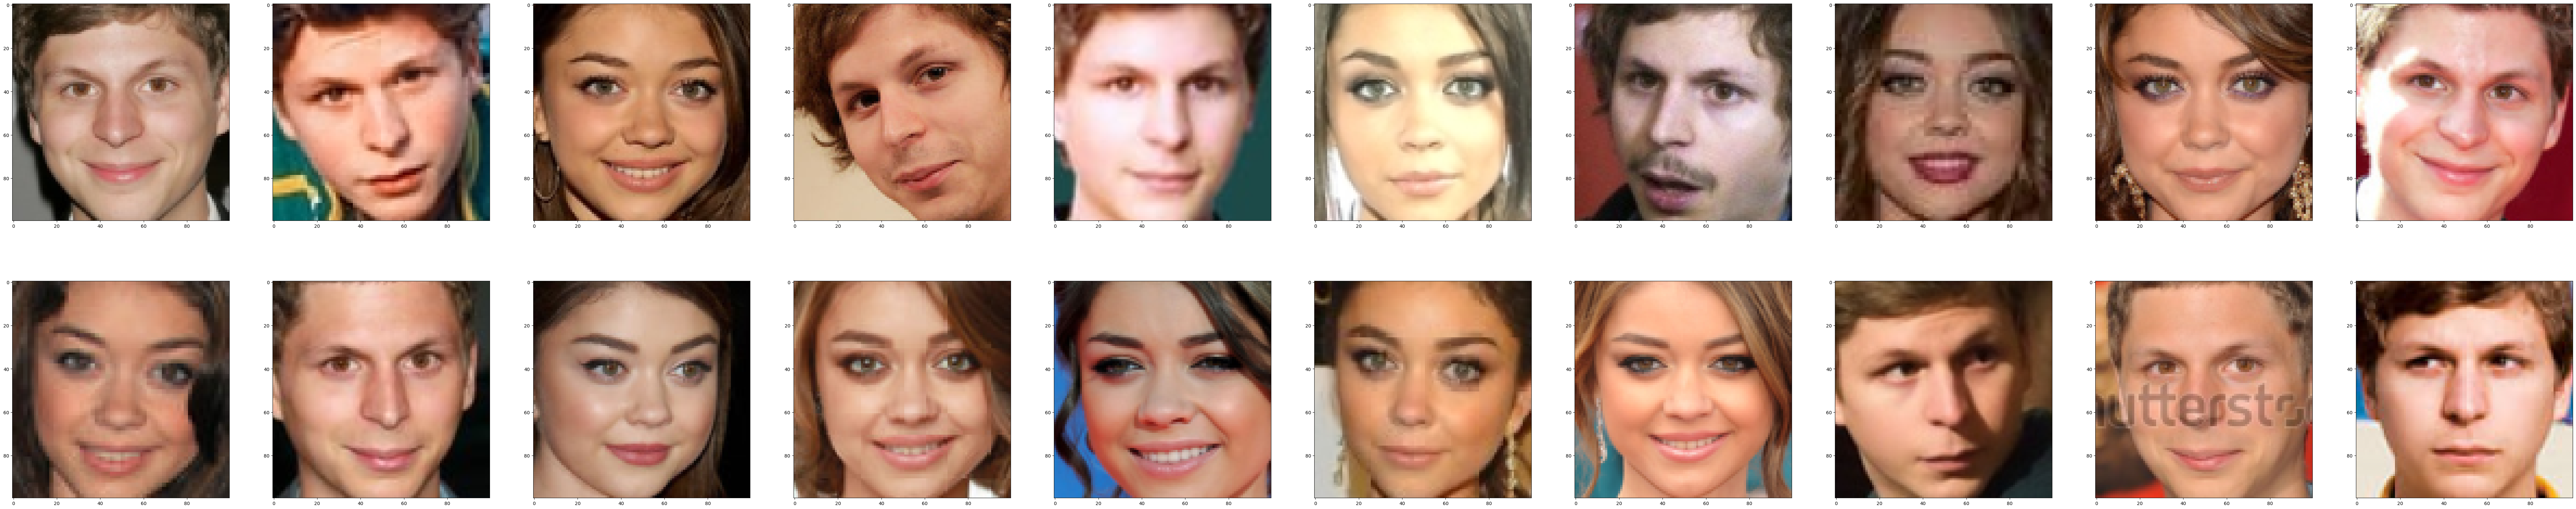

In [15]:
# plot faces of Michael and Sarah

plot_image_sequence(train_X[train_y == 0], n=20, imgs_per_row=10)

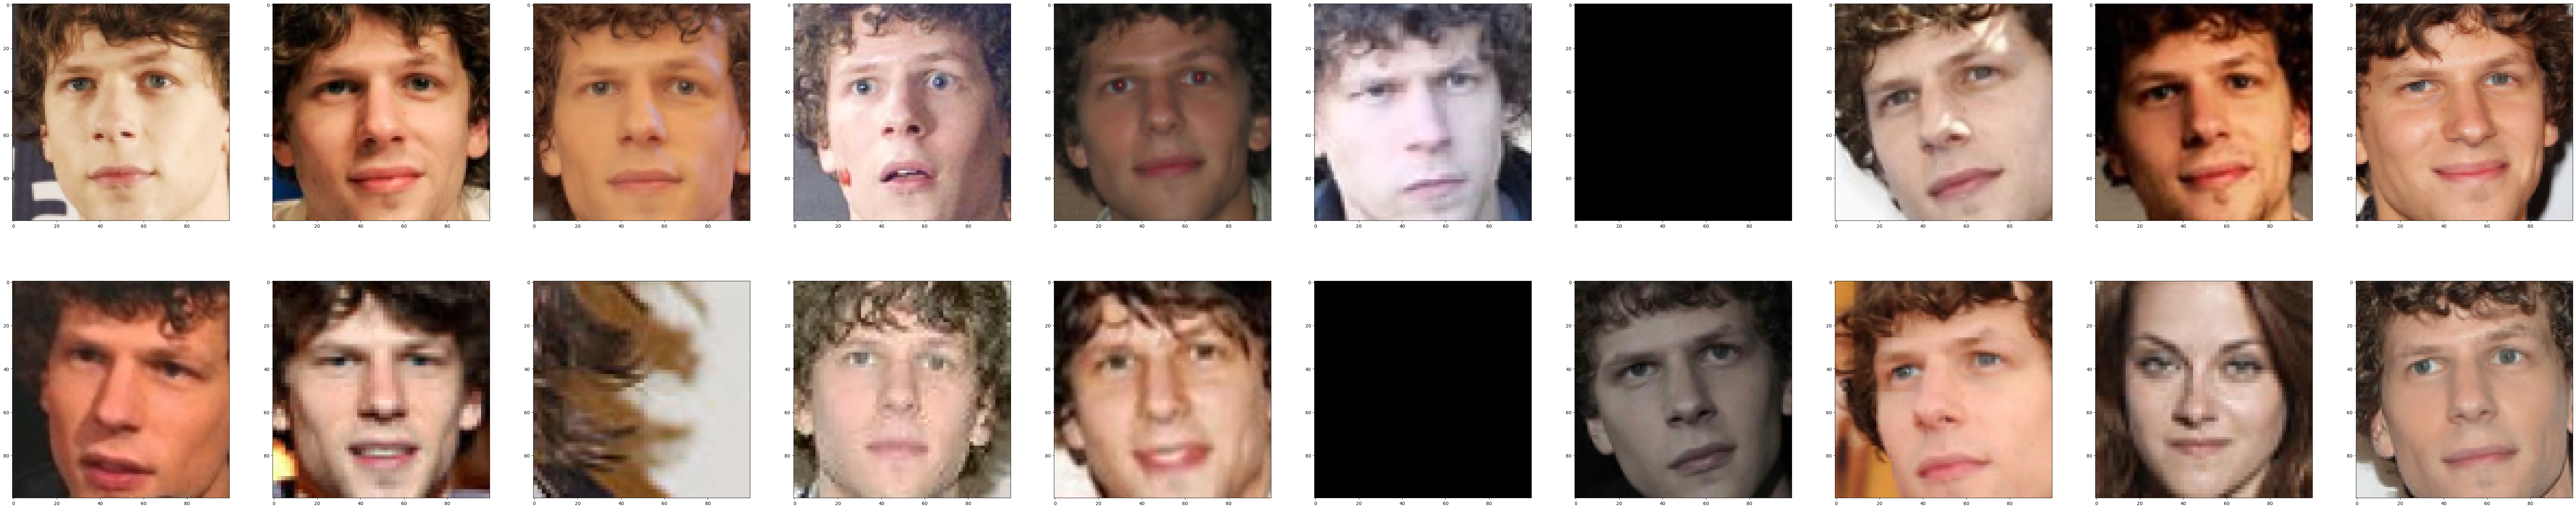

In [16]:
# plot faces of Jesse

plot_image_sequence(train_X[train_y == 1], n=20, imgs_per_row=10)

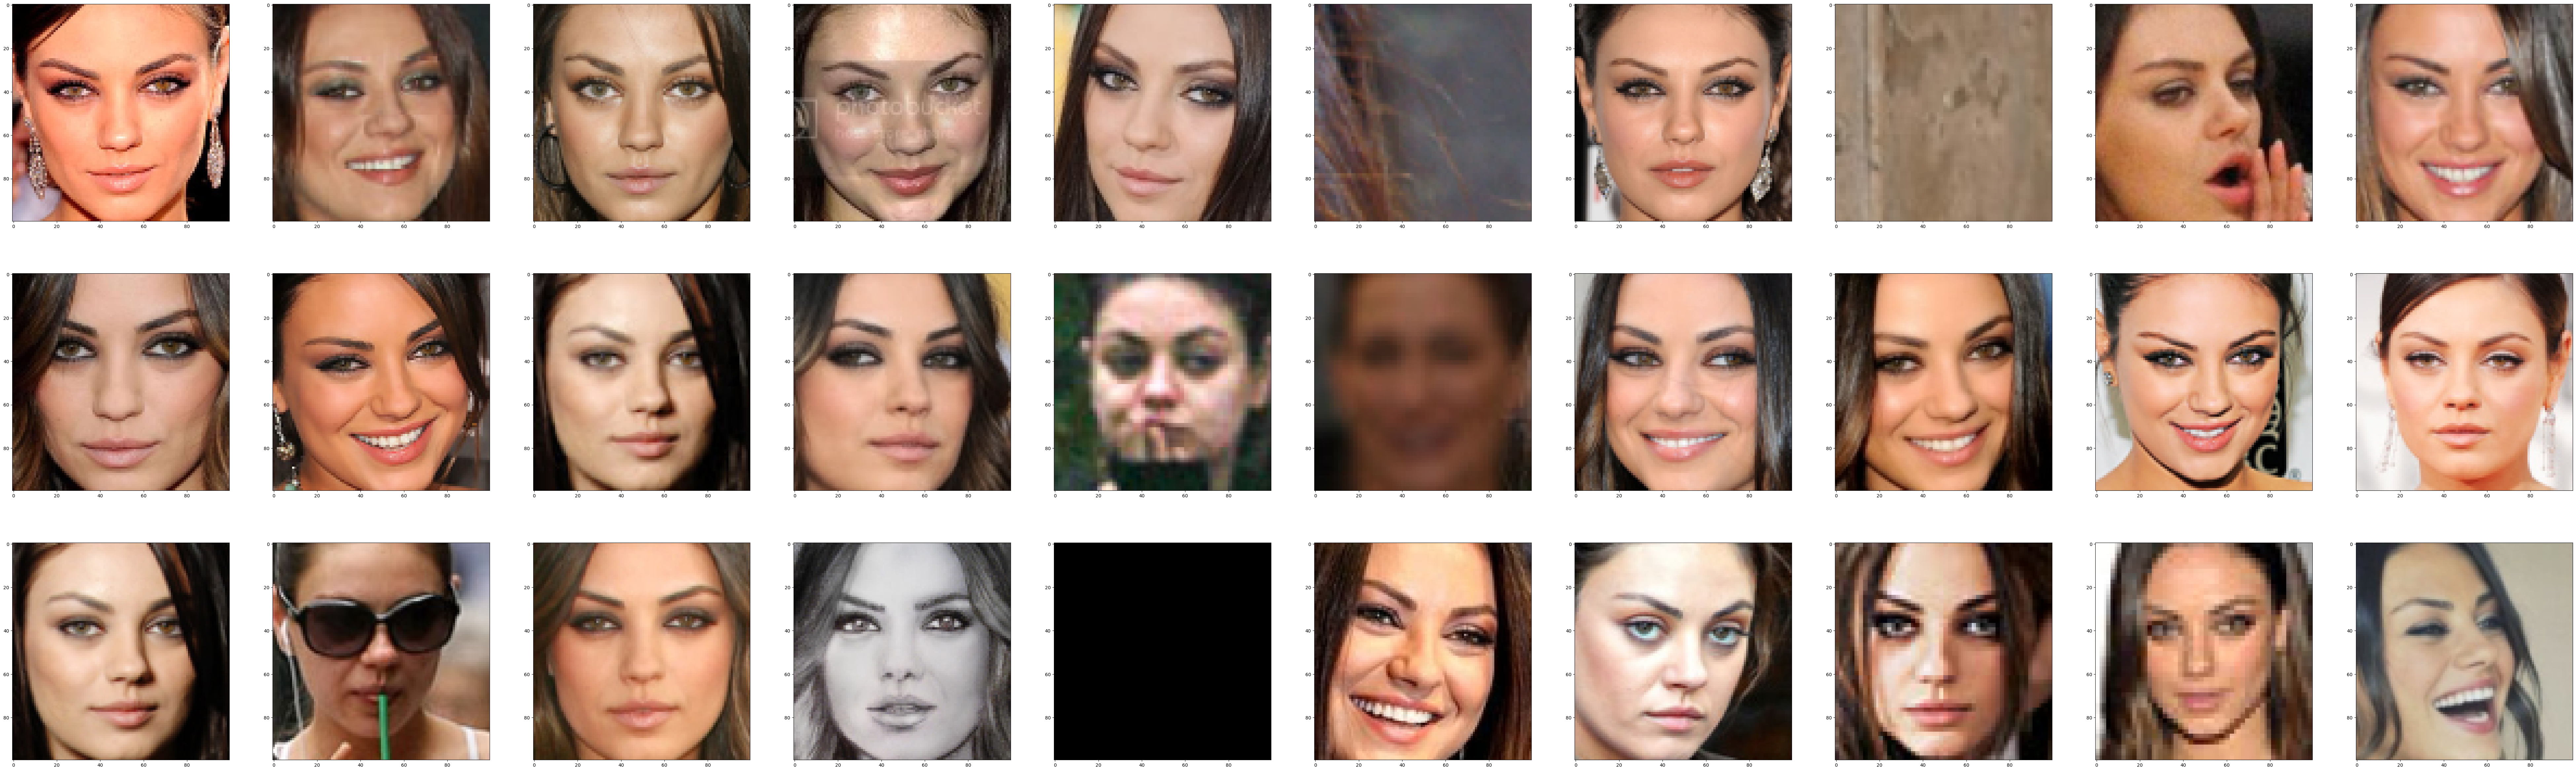

In [17]:
# plot faces of Mila

plot_image_sequence(train_X[train_y == 2], n=30, imgs_per_row=10)

## 0.4. Store Preprocessed data (optional)
<div class="alert alert-block alert-info">
<b>NOTE:</b> You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All". Feel free to use this to store intermediary results.
</div>

Saving the preproccessed data

In [18]:
# prep_path = './kaggle/working/prepped_data/'
# if not os.path.exists(prep_path):
#     os.mkdir(prep_path)
    
# np.save(os.path.join(prep_path, 'train_X.npy'), train_X)
# np.save(os.path.join(prep_path, 'train_y.npy'), train_y)
# np.save(os.path.join(prep_path, 'test_X.npy'), test_X)

Loading the preproccessed data

In [19]:
# prep_path = './kaggle/working/prepped_data/'
# if not os.path.exists(prep_path):
#     os.mkdir(prep_path)
# train_X = np.load(os.path.join(prep_path, 'train_X.npy'))
# train_y = np.load(os.path.join(prep_path, 'train_y.npy'))
# test_X = np.load(os.path.join(prep_path, 'test_X.npy'))

Now we are ready to rock!

# 1. Feature Representations
## 1.0. Example: Identify feature extractor
Our example feature extractor doesn't actually do anything... It just returns the input:
$$
\forall x : f(x) = x.
$$

It does make for a good placeholder and baseclass ;).

In [20]:
class IdentityFeatureExtractor:
    """A simple function that returns the input"""
    
    def transform(self, X):
        return X
    
    def __call__(self, X):
        return self.transform(X)


## 1.1. Baseline 1: HOG feature extractor/Scale Invariant Feature Transform
...

In [21]:
class HOGFeatureExtractor(IdentityFeatureExtractor):

    
    def __init__(self, **params):
        self.params = {
            'orientations': 9,
            'pixels_per_cell': (12, 12),
            'cells_per_block': (3, 3),
            'block_norm': 'L2-Hys',
            'visualize': False,
            'channel_axis': -1,
            'feature_vector': True
        }
       
        self.params.update(params)
        
    def transform(self, X):
        """
        Transform an array of images into HOG features.
        """
    
        # if not isinstance(X, np.ndarray):
        #     X = np.array(X)
        
    
        nan_mask = np.isnan(X).any(axis=(1,2,3)) if X.ndim == 4 else np.isnan(X).any(axis=(1,2))
   
        features = []
        
        for i, img in enumerate(X):
            if nan_mask[i]:

                dummy_img = np.zeros_like(X[0])
                dummy_features = hog(dummy_img, **self.params)
                features.append(np.zeros_like(dummy_features))
            else:
                if img.dtype == np.uint8:
                    img = img / 255.0
                
                features.append(hog(img, **self.params))
        
        return np.array(features)

### 1.1.1. t-SNE Plots
...

Forme des caractéristiques HOG: (320, 3969)


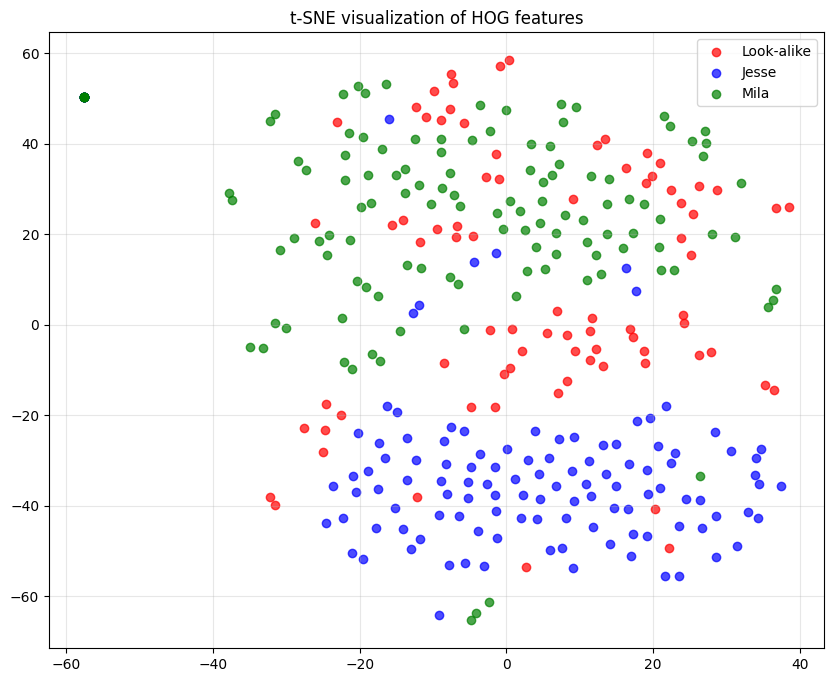

Évaluation de l'extracteur HOG:
Accuracy: 0.9281 ± 0.0351


In [22]:
# Testons notre extracteur HOG
hog_extractor = HOGFeatureExtractor(
    orientations=9,
    pixels_per_cell=(11, 11),
    cells_per_block=(3, 3),
    block_norm='L2-Hys'
)

# Extraire les caractéristiques HOG des images d'entraînement
train_hog_features = hog_extractor.transform(train_X)

print(f"Forme des caractéristiques HOG: {train_hog_features.shape}")

def plot_tsne_2d(features, labels, title="t-SNE visualization of features"):
    """Plot t-SNE visualization of features"""

    tsne = TSNE(n_components=2, random_state=42)
    features_2d = tsne.fit_transform(features)
    
    colors = {0: 'red', 1: 'blue', 2: 'green'}
    label_names = {0: 'Look-alike', 1: 'Jesse', 2: 'Mila'}
    
    plt.figure(figsize=(10, 8))
    for label in np.unique(labels):
        idx = labels == label
        plt.scatter(features_2d[idx, 0], features_2d[idx, 1], 
                   c=colors[label], label=label_names[label], alpha=0.7)
    
    plt.title(title)
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()


# Visualiser les caractéristiques HOG avec t-SNE
plot_tsne_2d(train_hog_features, train_y, "t-SNE visualization of HOG features")



# Test de performance avec validation croisée
def evaluate_feature_extractor(feature_extractor, X, y, cv=5):
    """Évalue un extracteur de caractéristiques avec un classifieur SVM"""
    # Extraire les caractéristiques
    features = feature_extractor.transform(X)
    
    # Créer un pipeline avec mise à l'échelle et SVM
    pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('svm', SVC(kernel='rbf', C=10, gamma='scale'))
    ])
    
    # Évaluer avec validation croisée
    scores = cross_val_score(pipeline, features, y, cv=cv, scoring='accuracy')
    
    print(f"Accuracy: {scores.mean():.4f} ± {scores.std():.4f}")
    return scores

print("Évaluation de l'extracteur HOG:")
hog_scores = evaluate_feature_extractor(hog_extractor, train_X, train_y)

### 1.1.2. Discussion
...

## 1.2. Baseline 2: PCA feature extractor
...

In [23]:
class PCAFeatureExtractor(IdentityFeatureExtractor):
    """Principal Component Analysis (PCA) Feature Extractor."""
    
    def __init__(self, n_components):
        self.n_components = n_components
        self.pca = None
    
    def fit(self, X):
        """Fit PCA on the dataset."""
        self.pca = PCA(n_components=self.n_components)
        self.pca.fit(X)
        return self
    
    def transform(self, X):
        """Transform input data using the trained PCA model."""
        if self.pca is None:
            raise ValueError("PCA model is not fitted yet. Call `fit` first.")
        return self.pca.transform(X)
    
    def inverse_transform(self, X):
        """Reconstruct the original data from the PCA-transformed representation."""
        if self.pca is None:
            raise ValueError("PCA model is not fitted yet. Call `fit` first.")
        return self.pca.inverse_transform(X)
    
    def __call__(self, X):
        return self.transform(X)


### 1.2.1. Eigenface Plots
...

In [24]:
# Map class labels to names for better visualization
name_mapping = {
    0: 'Michael_Cera_and_Sarah',  # Look-alikes
    1: 'Jesse',
    2: 'Mila_Kunis'
}

In [27]:
def create_eigenfaces(train_X, n_components=40):
    """
    Create PCA model for eigenfaces.
    
    Parameters:
    -----------
    train_X : numpy.ndarray
        Training data with shape (n_samples, height, width, channels)
    n_components : int, default=40
        Number of principal components to extract
        
    Returns:
    --------
    pca_extractor : sklearn.decomposition.PCA
        Fitted PCA model
    """
    # Reshape images to 2D array (samples x features)
    X_reshaped = train_X.reshape(train_X.shape[0], -1)
    
    # Create and fit PCA model
    pca_extractor = PCA(n_components=n_components)
    pca_extractor.fit(X_reshaped)
    
    return pca_extractor


def plot_eigenfaces(pca_extractor, FACE_SIZE, n_components_to_plot=9):
    """
    Plot eigenfaces (principal components) from a PCA model.
    
    Parameters:
    -----------
    pca_extractor : sklearn.decomposition.PCA
        Fitted PCA model
    FACE_SIZE : tuple
        Size of the face images (height, width)
    n_components_to_plot : int, default=9
        Number of eigenfaces to plot
    """
    plt.figure(figsize=(15, 8))

    # Plot the mean face first
    mean_face = pca_extractor.mean_.reshape(FACE_SIZE + (3,))
    plt.subplot(3, n_components_to_plot//2 + 1, 1)
    plt.title("Mean Face", fontsize=12)
    plt.imshow(mean_face)
    plt.axis('off')

    # Plot the eigenfaces
    for i in range(n_components_to_plot):
        plt.subplot(3, n_components_to_plot//2 + 1, i + 2)
        # Reshape and normalize the eigenvector for visualization
        eigenface = pca_extractor.components_[i].reshape(FACE_SIZE + (3,))
        eigenface = (eigenface - eigenface.min()) / (eigenface.max() - eigenface.min())
        plt.title(f"Eigenface {i+1}", fontsize=10)
        plt.imshow(eigenface)
        plt.axis('off')

    plt.tight_layout()
    plt.suptitle("Eigenfaces (Principal Components)", fontsize=16, y=0.98)
    plt.subplots_adjust(top=0.9)
    plt.show()


def plot_face_reconstruction(train_X, train_y, name_mapping, FACE_SIZE, n_samples=3, component_levels=[5, 15, 30]):
    """
    Visualize face reconstruction using different numbers of principal components.
    Handles uint8 input data properly.
    
    Parameters:
    -----------
    train_X : numpy.ndarray
        Training data with shape (n_samples, height, width, channels) in uint8 format
    train_y : numpy.ndarray
        Training labels
    name_mapping : dict
        Mapping from class indices to names
    FACE_SIZE : tuple
        Size of the face images (height, width)
    n_samples : int, default=3
        Number of samples to select from each class
    component_levels : list, default=[5, 15, 30]
        List of component counts to use for reconstruction
    """
    plt.figure(figsize=(15, 10))

    # Select some sample faces from each class
    sample_indices = []
    for class_id in range(len(name_mapping)):
        indices = np.where(train_y == class_id)[0]
        if len(indices) >= n_samples:
            sample_indices.extend(np.random.choice(indices, n_samples, replace=False))
        else:
            sample_indices.extend(indices)  # Use all available if less than n_samples

    # Original faces row
    for i, idx in enumerate(sample_indices):
        plt.subplot(4, len(sample_indices), i+1)
        plt.title(f"Original: {name_mapping[train_y[idx]]}", fontsize=8)
        plt.imshow(train_X[idx])
        plt.axis('off')

    # Convert to float32 for processing (preserving the original uint8 data)
    X_float = train_X.astype(np.uint8)
    
    # Reshape data for PCA
    X_reshaped = X_float.reshape(X_float.shape[0], -1)
    
    # Reconstructions with increasing numbers of components
    for row, n_comp in enumerate(component_levels):
        reduced_pca = PCA(n_components=n_comp)
        reduced_features = reduced_pca.fit_transform(X_reshaped)
        reconstructed = reduced_pca.inverse_transform(reduced_features)
        
        for i, idx in enumerate(sample_indices):
            plt.subplot(4, len(sample_indices), (row+1)*len(sample_indices) + i+1)
            rec_img = reconstructed[idx].reshape(FACE_SIZE + (3,))
            
            # Ensure values are in valid range for uint8 and convert back
            rec_img = np.clip(rec_img, 0, 255).astype(np.uint8)
            plt.imshow(rec_img)
            plt.title(f"{n_comp} components", fontsize=8)
            plt.axis('off')

    plt.tight_layout()
    plt.suptitle("Face Reconstruction using PCA", fontsize=16, y=0.98)
    plt.subplots_adjust(top=0.9)
    plt.show()


def plot_variance_explained(pca_extractor):
    """
    Display variance explained by principal components.
    
    Parameters:
    -----------
    pca_extractor : sklearn.decomposition.PCA
        Fitted PCA model
    
    Returns:
    --------
    components_for_90_percent : int
        Number of components needed to preserve 90% of variance
    """
    plt.figure(figsize=(10, 4))
    explained_var = pca_extractor.explained_variance_ratio_
    cumulative_var = np.cumsum(explained_var)
    components = range(1, len(explained_var) + 1)

    plt.subplot(1, 2, 1)
    plt.bar(components[:20], explained_var[:20], alpha=0.7)
    plt.title("Variance Explained by Each Component")
    plt.xlabel("Principal Component")
    plt.ylabel("Explained Variance Ratio")
    plt.grid(alpha=0.3)

    plt.subplot(1, 2, 2)
    plt.plot(components[:50], cumulative_var[:50], 'o-', markersize=4)
    plt.axhline(y=0.9, color='r', linestyle='--', alpha=0.7)
    plt.axhline(y=0.95, color='g', linestyle='--', alpha=0.7)
    plt.title("Cumulative Explained Variance")
    plt.xlabel("Number of Components")
    plt.ylabel("Cumulative Explained Variance")
    plt.grid(alpha=0.3)
    
    components_for_90_percent = np.where(cumulative_var >= 0.9)[0][0] + 1
    print(f"Number of components needed to preserve 90% of variance: {components_for_90_percent}")
    
    return components_for_90_percent

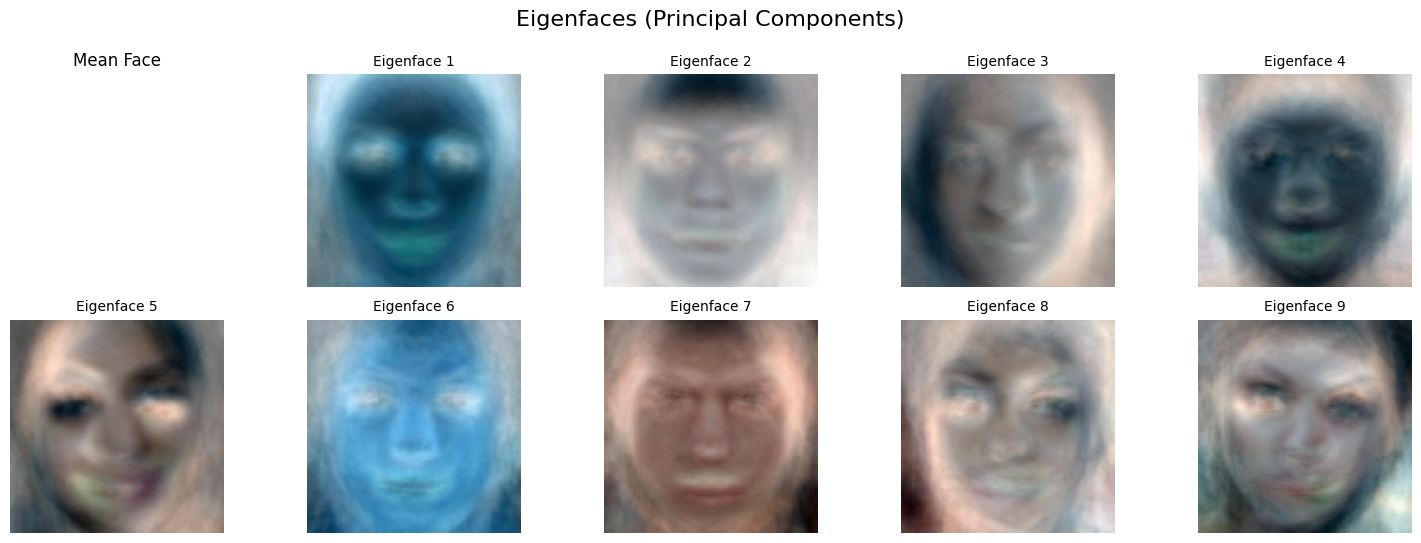

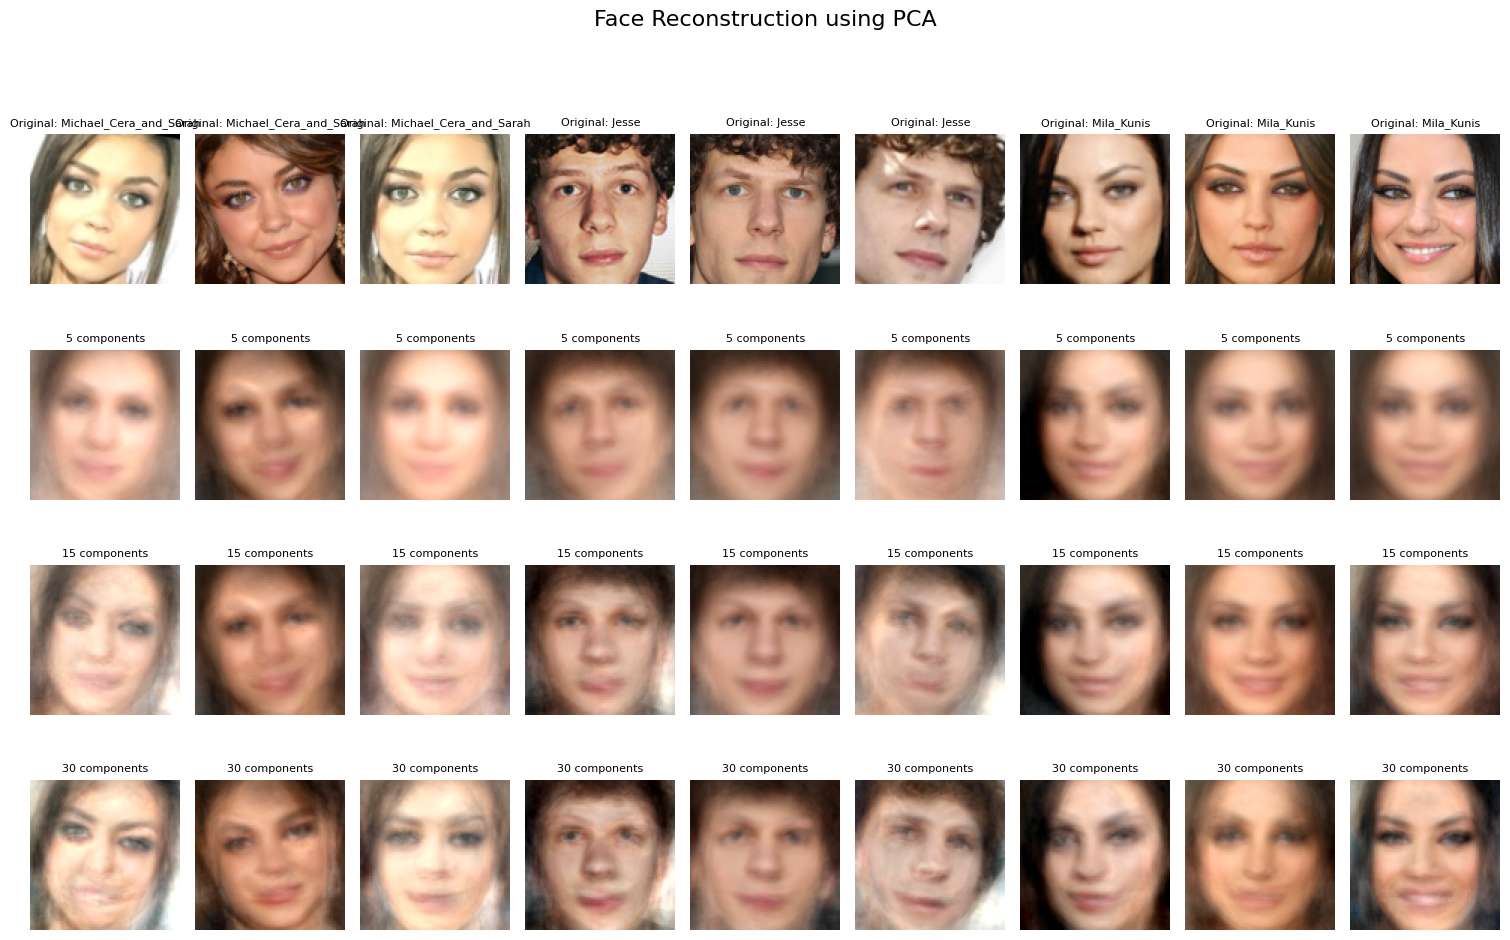

Number of components needed to preserve 90% of variance: 54


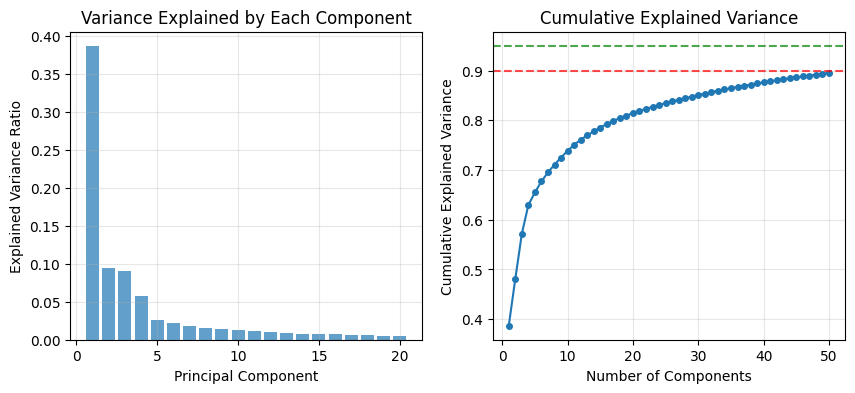

In [29]:
# Define parameters
n_components = 80
n_components_to_plot = 9
n_samples = 3

# Map class labels to names for better visualization
name_mapping = {
    0: 'Michael_Cera_and_Sarah',  # Look-alikes
    1: 'Jesse',
    2: 'Mila_Kunis'
}

new_train_X = train_X.astype(np.uint8)  
# Create and fit PCA model
pca_extractor = create_eigenfaces(new_train_X, n_components=n_components)

# Plot eigenfaces
plot_eigenfaces(pca_extractor, FACE_SIZE, n_components_to_plot)

# Plot face reconstruction
plot_face_reconstruction(new_train_X, train_y, name_mapping, FACE_SIZE, n_samples)

# Plot variance explained
components_for_90_percent = plot_variance_explained(pca_extractor)

### 1.2.2. Feature Space Plots
...

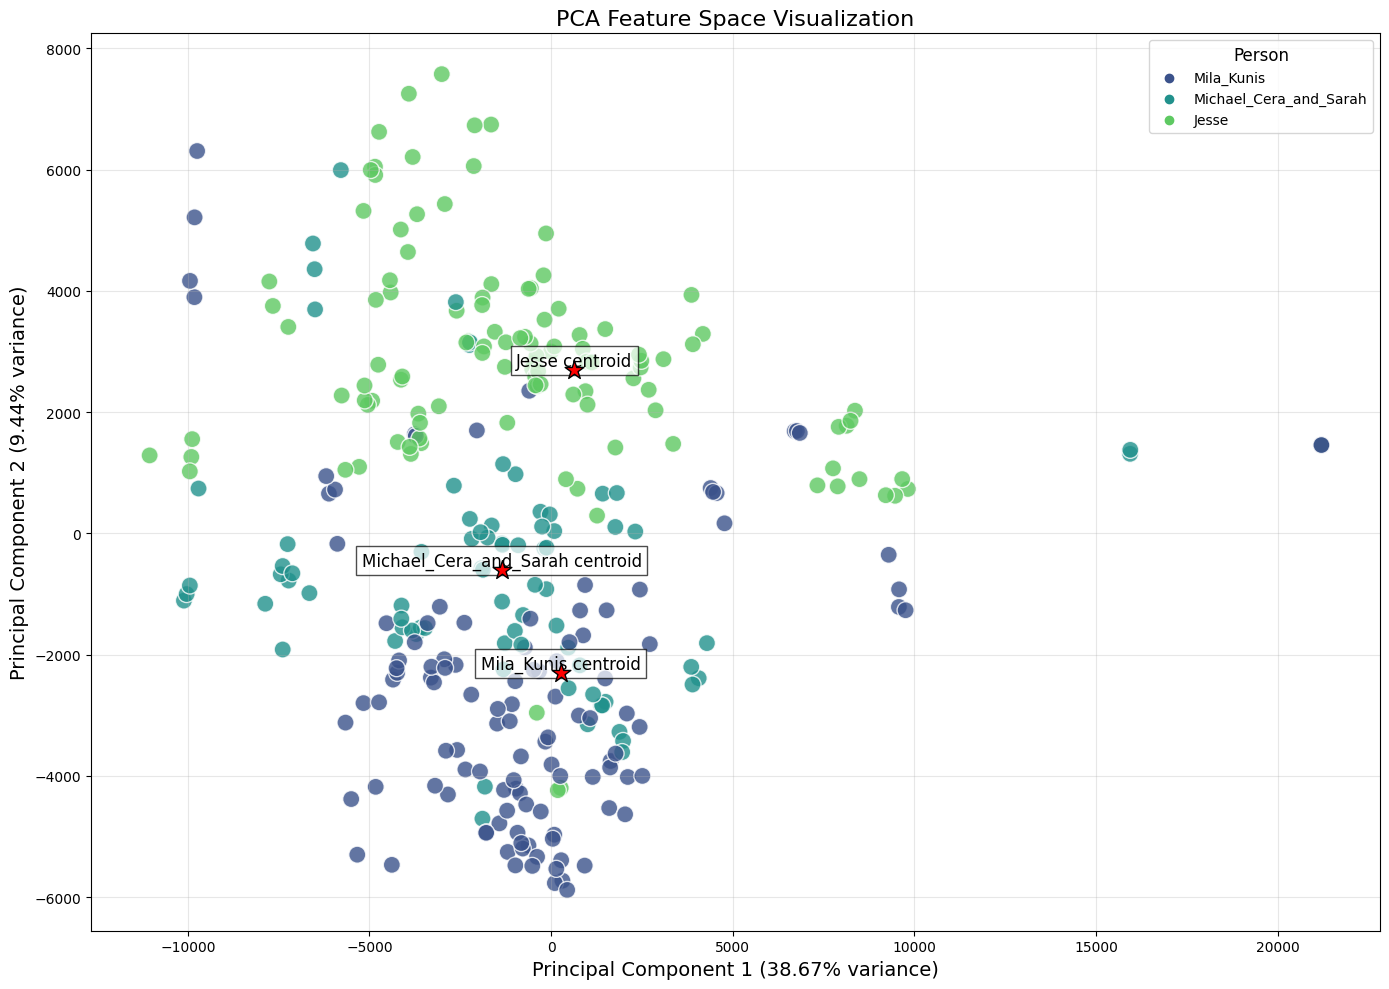

PCA Feature Space Analysis:
Total explained variance in 2D: 85.06%

Mila_Kunis:
  Number of samples: 120
  Centroid: (267.84, -2296.93)
  Spread (std dev): 6045.01, 2561.29
  Distance to Michael_Cera_and_Sarah centroid: 2351.63
  Distance to Jesse centroid: 5005.35

Michael_Cera_and_Sarah:
  Number of samples: 80
  Centroid: (-1356.90, -596.81)
  Spread (std dev): 5156.64, 1981.61
  Distance to Mila_Kunis centroid: 2351.63
  Distance to Jesse centroid: 3848.30

Jesse:
  Number of samples: 120
  Centroid: (636.76, 2694.81)
  Spread (std dev): 6999.34, 1889.87
  Distance to Mila_Kunis centroid: 5005.35
  Distance to Michael_Cera_and_Sarah centroid: 3848.30


In [30]:
# Prepare data for visualization (flatten images)
train_X_flat = new_train_X.reshape(train_X.shape[0], -1)

# Apply PCA to reduce to 2 dimensions for visualization
reduced_pca = PCA(n_components=30)
pca_2d = reduced_pca.fit_transform(train_X_flat)

# Create a DataFrame for easier plotting
df_pca = pd.DataFrame({
    'PC1': pca_2d[:, 0],
    'PC2': pca_2d[:, 1],
    'Class': train_y
})


df_pca['Name'] = df_pca['Class'].map(name_mapping)

# Create a more visually appealing plot
plt.figure(figsize=(14, 10))
sns.scatterplot(
    x='PC1', y='PC2',
    hue='Name',
    data=df_pca,
    palette='viridis',
    s=150,
    alpha=0.8
)

# Add annotations and styling
plt.title('PCA Feature Space Visualization', fontsize=16)
plt.xlabel(f'Principal Component 1 ({reduced_pca.explained_variance_ratio_[0]:.2%} variance)', fontsize=14)
plt.ylabel(f'Principal Component 2 ({reduced_pca.explained_variance_ratio_[1]:.2%} variance)', fontsize=14)
plt.legend(title='Person', title_fontsize=12, fontsize=10)

# Improve plot aesthetics
plt.grid(alpha=0.3)
plt.tight_layout()

# Draw confidence ellipses for each class
for class_id, name in name_mapping.items():
    subset = df_pca[df_pca['Class'] == class_id]
    # Calculate centroid
    centroid_x = subset['PC1'].mean()
    centroid_y = subset['PC2'].mean()
    plt.scatter(centroid_x, centroid_y, s=200, marker='*', color='red', edgecolor='black', zorder=10)
    plt.text(centroid_x, centroid_y, f"{name} centroid", fontsize=12, 
             ha='center', va='bottom', bbox=dict(facecolor='white', alpha=0.7))

plt.show()

# Print some metrics about class separation
print("PCA Feature Space Analysis:")
total_var = reduced_pca.explained_variance_ratio_.sum()
print(f"Total explained variance in 2D: {total_var:.2%}")

# Calculate between-class and within-class distances
for class_name in df_pca['Name'].unique():
    class_data = df_pca[df_pca['Name'] == class_name]
    print(f"\n{class_name}:")
    print(f"  Number of samples: {len(class_data)}")
    print(f"  Centroid: ({class_data['PC1'].mean():.2f}, {class_data['PC2'].mean():.2f})")
    print(f"  Spread (std dev): {class_data['PC1'].std():.2f}, {class_data['PC2'].std():.2f}")
    
    # Calculate distances to other classes
    for other_class in df_pca['Name'].unique():
        if other_class != class_name:
            other_data = df_pca[df_pca['Name'] == other_class]
            # Distance between centroids
            dist = ((class_data['PC1'].mean() - other_data['PC1'].mean())**2 + 
                    (class_data['PC2'].mean() - other_data['PC2'].mean())**2)**0.5
            print(f"  Distance to {other_class} centroid: {dist:.2f}")

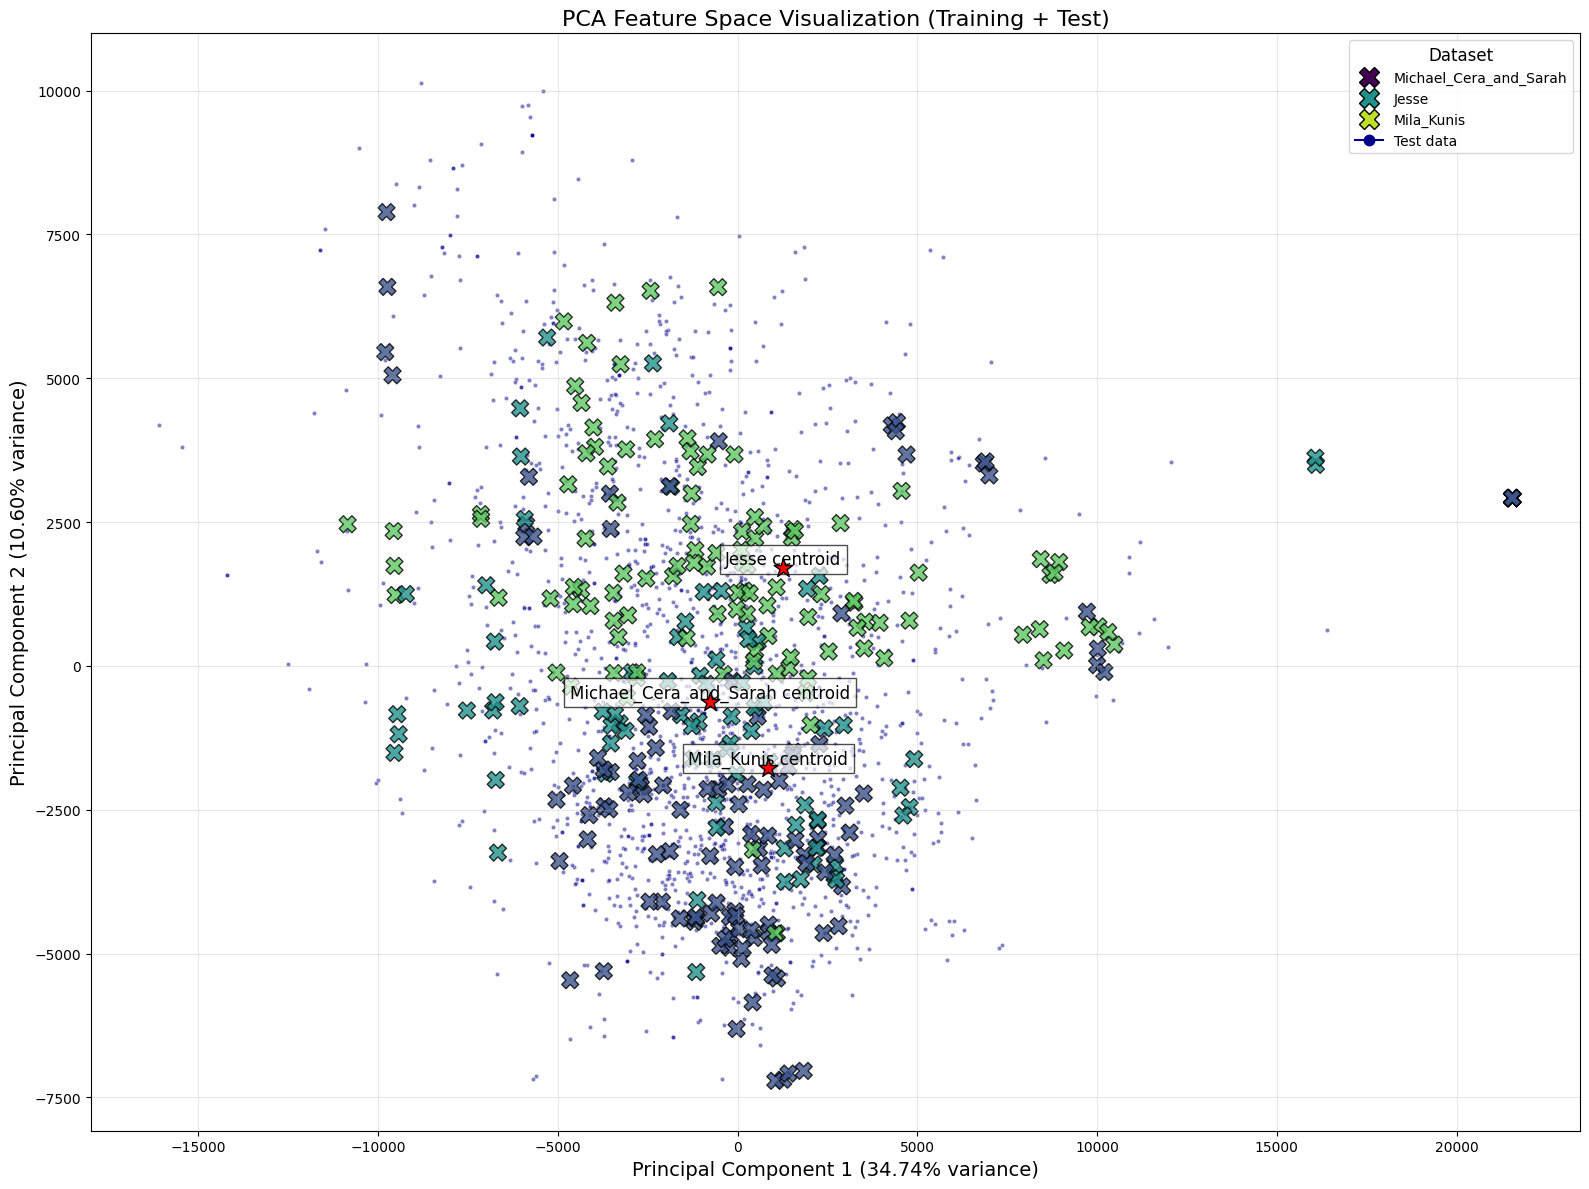

PCA Feature Space Analysis:
Total explained variance in 2D: 45.34%
Total training samples: 320
Total test samples: 1816

Mila_Kunis:
  Number of samples: 120
  Centroid: (848.04, -1767.27)
  Spread (std dev): 6009.78, 3254.77
  Distance to Michael_Cera_and_Sarah centroid: 1981.30
  Distance to Jesse centroid: 3492.97

Michael_Cera_and_Sarah:
  Number of samples: 80
  Centroid: (-767.29, -619.98)
  Spread (std dev): 5148.87, 2250.69
  Distance to Mila_Kunis centroid: 1981.30
  Distance to Jesse centroid: 3089.89

Jesse:
  Number of samples: 120
  Centroid: (1274.00, 1699.63)
  Spread (std dev): 6971.85, 1835.57
  Distance to Mila_Kunis centroid: 3492.97
  Distance to Michael_Cera_and_Sarah centroid: 3089.89


In [31]:
from sklearn.decomposition import PCA
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Prepare data for visualization (flatten images)
train_X_flat = new_train_X.reshape(train_X.shape[0], -1)
test_X_flat = test_X.reshape(test_X.shape[0], -1).astype(np.uint8)

# Combine train and test data for PCA fitting
combined_data = np.vstack([train_X_flat, test_X_flat])

# Apply PCA to reduce to 2 dimensions for visualization
reduced_pca = PCA(n_components=2)
combined_pca_2d = reduced_pca.fit_transform(combined_data)

# Split back into train and test
train_pca_2d = combined_pca_2d[:len(train_X_flat)]
test_pca_2d = combined_pca_2d[len(train_X_flat):]

# Create DataFrames for easier plotting
df_train_pca = pd.DataFrame({
    'PC1': train_pca_2d[:, 0],
    'PC2': train_pca_2d[:, 1],
    'Class': train_y,
    'Dataset': 'Training'
})

# For test data, we don't have labels, so assign a placeholder
df_test_pca = pd.DataFrame({
    'PC1': test_pca_2d[:, 0],
    'PC2': test_pca_2d[:, 1],
    'Class': [-1] * len(test_X),  # Placeholder class
    'Dataset': 'Test'
})

# Map class names for training data
df_train_pca['Name'] = df_train_pca['Class'].map(name_mapping)

# Combine for plotting
df_combined_pca = pd.concat([df_train_pca, df_test_pca])

# Create a more visually appealing plot
plt.figure(figsize=(16, 12))

# Plot test data with more prominence
sns.scatterplot(
    x='PC1', y='PC2',
    data=df_test_pca,
    color='darkblue',  # Darker color for visibility
    s=40,              # Larger point size
    alpha=0.5,         # More opacity
    label='Test data',
    marker='.'         # Dot marker
)

# Plot training data with distinct markers
sns.scatterplot(
    x='PC1', y='PC2',
    hue='Name',
    data=df_train_pca,
    palette='viridis',
    s=150,
    alpha=0.8,
    marker='X',        # X marker to distinguish from test data
    edgecolor='black'  # Black edge for better visibility
)

# Add annotations and styling
plt.title('PCA Feature Space Visualization (Training + Test)', fontsize=16)
plt.xlabel(f'Principal Component 1 ({reduced_pca.explained_variance_ratio_[0]:.2%} variance)', fontsize=14)
plt.ylabel(f'Principal Component 2 ({reduced_pca.explained_variance_ratio_[1]:.2%} variance)', fontsize=14)

# Create a custom legend
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], marker='X', color='w', markerfacecolor=plt.cm.viridis(0), 
           markersize=15, label=list(name_mapping.values())[0], markeredgecolor='black'),
    Line2D([0], [0], marker='X', color='w', markerfacecolor=plt.cm.viridis(0.5), 
           markersize=15, label=list(name_mapping.values())[1], markeredgecolor='black'),
    Line2D([0], [0], marker='X', color='w', markerfacecolor=plt.cm.viridis(0.9), 
           markersize=15, label=list(name_mapping.values())[2], markeredgecolor='black'),
    Line2D([0], [0], marker='.', color='darkblue', 
           markersize=15, label='Test data')
]
plt.legend(handles=legend_elements, title='Dataset', title_fontsize=12, fontsize=10)

# Improve plot aesthetics
plt.grid(alpha=0.3)
plt.tight_layout()

# Draw confidence ellipses for each class
for class_id, name in name_mapping.items():
    subset = df_train_pca[df_train_pca['Class'] == class_id]
    # Calculate centroid
    centroid_x = subset['PC1'].mean()
    centroid_y = subset['PC2'].mean()
    plt.scatter(centroid_x, centroid_y, s=200, marker='*', color='red', edgecolor='black', zorder=10)
    plt.text(centroid_x, centroid_y, f"{name} centroid", fontsize=12, 
             ha='center', va='bottom', bbox=dict(facecolor='white', alpha=0.7))

plt.show()

# Print some metrics about class separation
print("PCA Feature Space Analysis:")
total_var = reduced_pca.explained_variance_ratio_.sum()
print(f"Total explained variance in 2D: {total_var:.2%}")
print(f"Total training samples: {len(df_train_pca)}")
print(f"Total test samples: {len(df_test_pca)}")

# Calculate between-class and within-class distances for training data
for class_name in df_train_pca['Name'].unique():
    class_data = df_train_pca[df_train_pca['Name'] == class_name]
    print(f"\n{class_name}:")
    print(f"  Number of samples: {len(class_data)}")
    print(f"  Centroid: ({class_data['PC1'].mean():.2f}, {class_data['PC2'].mean():.2f})")
    print(f"  Spread (std dev): {class_data['PC1'].std():.2f}, {class_data['PC2'].std():.2f}")
    
    # Calculate distances to other classes
    for other_class in df_train_pca['Name'].unique():
        if other_class != class_name:
            other_data = df_train_pca[df_train_pca['Name'] == other_class]
            # Distance between centroids
            dist = ((class_data['PC1'].mean() - other_data['PC1'].mean())**2 + 
                    (class_data['PC2'].mean() - other_data['PC2'].mean())**2)**0.5
            print(f"  Distance to {other_class} centroid: {dist:.2f}")

### 1.2.3. Discussion

...

# 2. Evaluation Metrics
## 2.0. Example: Accuracy
As example metric we take the accuracy. Informally, accuracy is the proportion of correct predictions over the total amount of predictions. It is used a lot in classification but it certainly has its disadvantages...

#### 1. Accuracy

In [32]:


# # Step 1: Extract features using your PCA feature extractor
# n_components = 30  # You can adjust this based on your variance analysis
# pca_extractor = PCAFeatureExtractor(n_components=n_components)

# # Assuming train_X is your flattened image data
# X_flattened = train_X.reshape(train_X.shape[0], -1)
# pca_extractor.fit(X_flattened)
# X_pca = pca_extractor.transform(X_flattened)

# # Step 2: Split data for evaluation (if not already split)
# # If you already have separate train and test sets, you can skip this step
# X_train, X_val, y_train, y_val = train_test_split(X_pca, train_y, test_size=0.2, random_state=42, stratify=train_y)

# # Step 3: Train a classifier
# classifier = SVC(kernel='linear', C=1.0)  # You can try different classifiers
# classifier.fit(X_train, y_train)

# # Step 4: Make predictions
# y_pred = classifier.predict(X_val)

# # Step 5: Calculate metrics
# accuracy = accuracy_score(y_val, y_pred)
# f1 = f1_score(y_val, y_pred, average='weighted')  # weighted average for multiclass
# report = classification_report(y_val, y_pred, target_names=list(name_mapping.values()))
# conf_matrix = confusion_matrix(y_val, y_pred)

# # Step 6: Print the results
# print(f"Accuracy: {accuracy:.4f}")
# print(f"F1 Score (weighted): {f1:.4f}")
# print("\nClassification Report:")
# print(report)

# # Step 7: Visualize the confusion matrix
# plt.figure(figsize=(8, 6))
# sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
#             xticklabels=list(name_mapping.values()),
#             yticklabels=list(name_mapping.values()))
# plt.xlabel('Predicted')
# plt.ylabel('True')
# plt.title('Confusion Matrix')
# plt.tight_layout()
# plt.show()

# 3. Classifiers
## 3.0. Example: The *'not so smart'* classifier
This random classifier is not very complicated. It makes predictions at random, based on the distribution obseved in the training set. **It thus assumes** that the class labels of the test set will be distributed similarly to the training set.

In [33]:
class RandomClassificationModel:
    """Random classifier, draws a random sample based on class distribution observed 
    during training."""
    
    def fit(self, X, y):
        """Adjusts the class ratio instance variable to the one observed in y. 

        Parameters
        ----------
        X : tensor
            Training set
        y : array
            Training set labels

        Returns
        -------
        self : RandomClassificationModel
        """
        
        self.classes, self.class_ratio = np.unique(y, return_counts=True)
        self.class_ratio = self.class_ratio / self.class_ratio.sum()
        return self
        
    def predict(self, X):
        """Samples labels for the input data. 

        Parameters
        ----------
        X : tensor
            dataset
            
        Returns
        -------
        y_star : array
            'Predicted' labels
        """

        np.random.seed(0)
        return np.random.choice(self.classes, size = X.shape[0], p=self.class_ratio)
    
    def __call__(self, X):
        return self.predict(X)
    

## 3.1. Baseline 1: My favorite classifier
...

In [34]:


class SVMClassificationModel:
    """Support Vector Machine classifier with customizable kernel."""
    
    def __init__(self, kernel='linear', C=1.0, gamma='scale'):
        """Initialize SVM classifier with specified parameters.
        
        Parameters
        ----------
        kernel : str, default='linear'
            Specifies the kernel type to be used in the algorithm.
            Options: 'linear', 'poly', 'rbf', 'sigmoid'.
        C : float, default=1.0
            Regularization parameter. The strength of the regularization is 
            inversely proportional to C.
        gamma : {'scale', 'auto'} or float, default='scale'
            Kernel coefficient for 'rbf', 'poly' and 'sigmoid' kernels.
        """
        self.model = SVC(kernel=kernel, C=C, gamma=gamma, probability=True)
    
    def fit(self, X, y):
        """Train the model using the training data.

        Parameters
        ----------
        X : array-like of shape (n_samples, n_features)
            Training vector, where n_samples is the number of samples and
            n_features is the number of features.
        y : array-like of shape (n_samples,)
            Target vector relative to X.

        Returns
        -------
        self : object
            Returns self.
        """
        self.model.fit(X, y)
        return self
        
    def predict(self, X):
        """Predict class labels for samples in X.

        Parameters
        ----------
        X : array-like of shape (n_samples, n_features)
            Samples.
            
        Returns
        -------
        y_pred : array-like of shape (n_samples,)
            Class labels for samples in X.
        """
        return self.model.predict(X)
    
    def predict_proba(self, X):
        """Return probability estimates for samples in X.
        
        Parameters
        ----------
        X : array-like of shape (n_samples, n_features)
            Samples.
            
        Returns
        -------
        y_proba : array-like of shape (n_samples, n_classes)
            The class probabilities for each sample.
        """
        return self.model.predict_proba(X)
    
    def __call__(self, X):
        return self.predict(X)


class DecisionTreeClassificationModel:
            """Decision Tree classifier with customizable parameters."""
            
            def __init__(self, max_depth=None, criterion='gini', min_samples_split=2):
                """Initialize Decision Tree classifier with specified parameters.
                
                Parameters
                ----------
                max_depth : int or None, default=None
                    The maximum depth of the tree. If None, nodes are expanded until all 
                    leaves are pure or contain less than min_samples_split samples.
                criterion : str, default='gini'
                    Function to measure the quality of a split. Supported criteria are 
                    'gini' for Gini impurity and 'entropy' for information gain.
                min_samples_split : int, default=2
                    The minimum number of samples required to split an internal node.
                """
                self.model = DecisionTreeClassifier(
                    max_depth=max_depth,
                    criterion=criterion,
                    min_samples_split=min_samples_split,
                    random_state=42
                )
            
            def fit(self, X, y):
                """Train the model using the training data.

                Parameters
                ----------
                X : array-like of shape (n_samples, n_features)
                    Training vector.
                y : array-like of shape (n_samples,)
                    Target vector relative to X.

                Returns
                -------
                self : object
                    Returns self.
                """
                self.model.fit(X, y)
                return self
                
            def predict(self, X):
                """Predict class labels for samples in X.

                Parameters
                ----------
                X : array-like of shape (n_samples, n_features)
                    Samples.
                    
                Returns
                -------
                y_pred : array-like of shape (n_samples,)
                    Class labels for samples in X.
                """
                return self.model.predict(X)
            
            def predict_proba(self, X):
                """Return probability estimates for samples in X.
                
                Parameters
                ----------
                X : array-like of shape (n_samples, n_features)
                    Samples.
                    
                Returns
                -------
                y_proba : array-like of shape (n_samples, n_classes)
                    The class probabilities for each sample.
                """
                return self.model.predict_proba(X)
            
            def __call__(self, X):
                return self.predict(X)

class FavoriteClassificationModel:
    """TODO: this classifier is under construction."""
    
    def fit(self, X, y):
        raise NotImplmentedError
        
    def predict(self, X):
        raise NotImplmentedError

# 4. Experiments
<div class="alert alert-block alert-info"> <b>NOTE:</b> Do <i>NOT</i> use this section to keep track of every little change you make in your code! Instead, highlight the most important findings and the major (best) pipelines that you've discovered.  
</div>
<br>

## 4.0. Example: basic pipeline
The basic pipeline takes any input and samples a label based on the class label distribution of the training set. As expected the performance is very poor, predicting approximately 1/4 correctly on the training set. There is a lot of room for improvement but this is left to you ;). 

In [39]:
feature_extractor = PCAFeatureExtractor(n_components=80)
train_X_reshaped = train_X.reshape(train_X.shape[0], -1)  # Flatten all but first dimension
feature_extractor.fit(train_X_reshaped)

classifier =DecisionTreeClassificationModel()
classifier.fit(feature_extractor(train_X_reshaped), train_y)

# model/final pipeline
model = lambda X: classifier(feature_extractor(X))

In [40]:
# evaluate performance of the model on the training set
train_y_star = model(train_X_reshaped)

"The performance on the training set is {:.2f}. This however, does not tell us much about the actual performance (generalisability).".format(
    accuracy_score(train_y, train_y_star), f1_score(train_y, train_y_star, average='weighted'))

print(accuracy_score(train_y, train_y_star))
print(f1_score(train_y, train_y_star, average='weighted'))
print(classification_report(train_y, train_y_star))
print(confusion_matrix(train_y, train_y_star))

0.978125
0.9781847579762177
              precision    recall  f1-score   support

           0       1.00      0.99      0.99        80
           1       0.94      1.00      0.97       120
           2       1.00      0.95      0.97       120

    accuracy                           0.98       320
   macro avg       0.98      0.98      0.98       320
weighted avg       0.98      0.98      0.98       320

[[ 79   1   0]
 [  0 120   0]
 [  0   6 114]]


In [41]:
# predict the labels for the test set 
test_X_reshaped = test_X.reshape(test_X.shape[0], -1)
test_y_star = model(test_X_reshaped)

print("The predictions for the test set are:")
test_y_star


The predictions for the test set are:


array([1, 1, 0, ..., 2, 2, 1])

# 5. Publishing best results

In [42]:
submission = test.copy().drop('img', axis = 1)
submission['class'] = test_y_star

submission

,class
id,
0,1
1,1
2,0
3,0
4,0
...,...
1811,0
1812,1
1813,2


In [43]:
submission.to_csv('submission.csv')

# 6. Discussion
...

In summary we contributed the following: 
* 
